In [1]:
import pandas as pd

# 1. Load your data
df = pd.read_csv('DFW_2025.csv', low_memory=False)

# 2. Count TOTAL homes sold by each broker
total_homes = df.groupby('list_broker_name_1').size().rename('Total_Listings')

# 3. Filter the data to ONLY look at new construction (2024 & 2025)
new_construction_df = df[df['yearBuilt'].isin([2024, 2025])]

# 4. Count NEW homes sold by each broker
new_homes = new_construction_df.groupby('list_broker_name_1').size().rename('New_Listings')

# 5. Combine these two counts into one table
builder_check = pd.concat([total_homes, new_homes], axis=1).fillna(0)

# 6. Calculate the percentage: (New Listings / Total Listings) * 100
builder_check['Percent_New'] = (builder_check['New_Listings'] / builder_check['Total_Listings']) * 100

# 7. Find the Homebuilders! 
# Let's say anyone with at least 5 listings, where 90%+ are new, is a builder.
homebuilders = builder_check[
    (builder_check['Total_Listings'] >= 5) & 
    (builder_check['Percent_New'] >= 90)
]

# Sort them from largest to smallest to see the biggest builders
homebuilders = homebuilders.sort_values('Total_Listings', ascending=False)

print(homebuilders)

                               Total_Listings  New_Listings  Percent_New
list_broker_name_1                                                      
Turner Mangum LLC                        2115        2094.0    99.007092
Meritage Homes Realty                    1032        1006.0    97.480620
Jeanette Anderson Real Estate            1012        1000.0    98.814229
William Roberds                           720         681.0    94.583333
DR Horton, America's Builder              717         695.0    96.931660
Escape Realty                             345         331.0    95.942029
Alexander Properties - Dallas             315         310.0    98.412698
Century Communities                       177         165.0    93.220339
Key Trek-CC                               154         146.0    94.805195
Master Key Realty                          39          39.0   100.000000
Belle Sage                                 13          12.0    92.307692
Conger Group Texas                          8      

In [4]:
# 1. Load your data with the low_memory fix to prevent the red warning
file_name = 'DFW_2025.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Fix and calculate the "Days on Market" columns
df['listingAddedDate'] = pd.to_datetime(df['listingAddedDate'], errors='coerce')
df['lastSoldDate'] = pd.to_datetime(df['lastSoldDate'], errors='coerce')
df['days_on_market'] = (df['lastSoldDate'] - df['listingAddedDate']).dt.days

# 3. Separate the Builder logic
total_homes = df.groupby('list_broker_name_1').size().rename('Total_Listings')
new_construction_df = df[df['yearBuilt'].isin([2024, 2025])]
new_homes = new_construction_df.groupby('list_broker_name_1').size().rename('New_Listings')

# 4. Combine counts and calculate the "New Construction %"
builder_check = pd.concat([total_homes, new_homes], axis=1).fillna(0)
builder_check['Percent_New'] = (builder_check['New_Listings'] / builder_check['Total_Listings']) * 100

# 5. Define who a builder is (At least 5 listings, 90%+ are brand new)
builder_filter = (builder_check['Total_Listings'] >= 5) & (builder_check['Percent_New'] >= 90)
top_builders = builder_check[builder_filter].index

# 6. Pull average AND median "Days on Market" for those specific builders
builder_stats = builders_only_df.groupby('list_broker_name_1')['days_on_market'].agg(['mean', 'median'])
builder_stats.columns = ['Avg_Days_On_Market', 'Median_Days_On_Market']

# 7. Create the MASTER Dashboard
# Combine the count/percentage data with the new stats
final_builder_dashboard = pd.concat([builder_check[builder_filter], builder_stats], axis=1)

# Round the numbers neatly and sort by the fastest median turnaround time
final_builder_dashboard['Percent_New'] = final_builder_dashboard['Percent_New'].round(1)
final_builder_dashboard['Avg_Days_On_Market'] = final_builder_dashboard['Avg_Days_On_Market'].round(1)
final_builder_dashboard['Median_Days_On_Market'] = final_builder_dashboard['Median_Days_On_Market'].round(1)

# Sort by the median (often a better indicator than mean for real estate)
final_builder_dashboard = final_builder_dashboard.sort_values('Median_Days_On_Market')

# Display the master table
print(final_builder_dashboard)

                               Total_Listings  New_Listings  Percent_New  \
list_broker_name_1                                                         
Master Key Realty                          39          39.0        100.0   
Turner Mangum LLC                        2115        2094.0         99.0   
Conger Group Texas                          8           8.0        100.0   
DR Horton, America's Builder              717         695.0         96.9   
Meritage Homes Realty                    1032        1006.0         97.5   
Jeanette Anderson Real Estate            1012        1000.0         98.8   
Escape Realty                             345         331.0         95.9   
William Roberds                           720         681.0         94.6   
Century Communities                       177         165.0         93.2   
Key Trek-CC                               154         146.0         94.8   
Alexander Properties - Dallas             315         310.0         98.4   
Belle Sage  

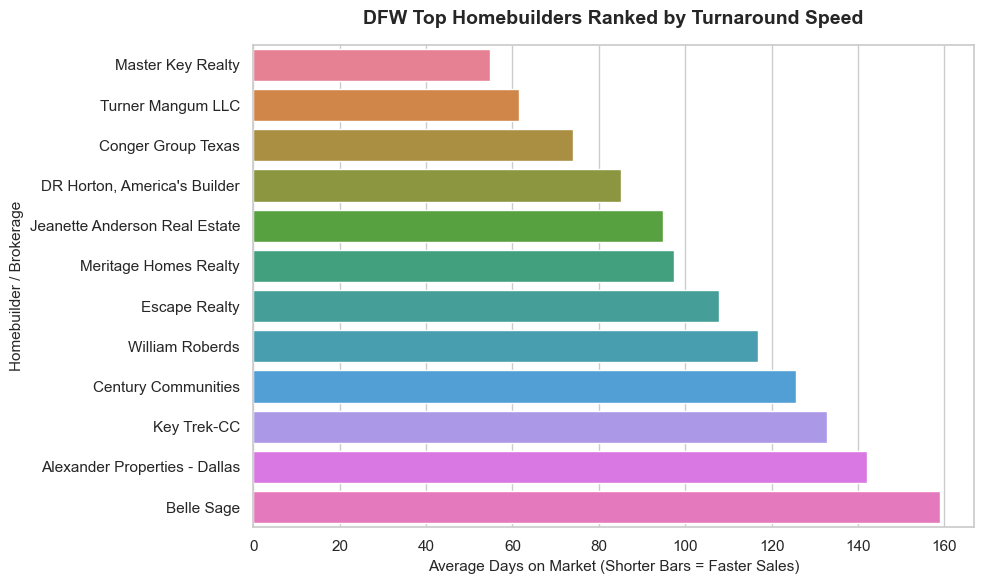

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set a clean, professional visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Create a horizontal bar chart mapping speed
sns.barplot(
    x='Avg_Days_On_Market', 
    y=final_builder_dashboard.index, 
    data=final_builder_dashboard,
    hue=final_builder_dashboard.index,
    legend=False
)

# 3. Add clean labels for your editor
plt.title('DFW Top Homebuilders Ranked by Turnaround Speed', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Days on Market (Shorter Bars = Faster Sales)', fontsize=11)
plt.ylabel('Homebuilder / Brokerage', fontsize=11)
plt.tight_layout()

# 4. Display the chart right inside your notebook
plt.show()

In [3]:
# 8. Calculate Global Market Benchmarks (For Context)
overall_market_avg = df['days_on_market'].mean()
overall_market_median = df['days_on_market'].median()

print("--- GLOBAL MARKET BENCHMARKS ---")
print(f"DFW Market Average (All Sales): {overall_market_avg:.1f} days")
print(f"DFW Market Median (All Sales):  {overall_market_median:.1f} days")
print("-" * 32)

# 9. Slice it by Resale vs. New Construction to be even more precise
# Create a temporary flag to split the data
df['is_new_build'] = df['yearBuilt'].isin([2024, 2025])

type_benchmarks = df.groupby('is_new_build')['days_on_market'].agg(['count', 'mean', 'median']).round(1)
type_benchmarks.index = ['Existing Resale', 'New Construction (All Builders)']
type_benchmarks.columns = ['Total Sales', 'Avg Days on Market', 'Median Days on Market']

print("\n--- BENCHMARKS BY PROPERTY TYPE ---")
print(type_benchmarks)

--- GLOBAL MARKET BENCHMARKS ---
DFW Market Average (All Sales): 86.9 days
DFW Market Median (All Sales):  66.0 days
--------------------------------

--- BENCHMARKS BY PROPERTY TYPE ---
                                 Total Sales  Avg Days on Market  \
Existing Resale                        67406                81.2   
New Construction (All Builders)        18581               107.6   

                                 Median Days on Market  
Existing Resale                                   59.0  
New Construction (All Builders)                   92.0  


In [6]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2025.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Fix the dates and calculate "Days on Market"
# The dates in your CSV have a "T" and "Z" (e.g., 2025-10-16T14:11:09.598Z)
# pandas handles this perfectly with to_datetime
df['listingAddedDate'] = pd.to_datetime(df['listingAddedDate'], errors='coerce')
df['lastSoldDate'] = pd.to_datetime(df['lastSoldDate'], errors='coerce')
df['days_on_market'] = (df['lastSoldDate'] - df['listingAddedDate']).dt.days

# 3. Filter strictly for homes built in 2024 and 2025
new_builds_df = df[df['yearBuilt'].isin([2024, 2025])]

# 4. Group by County and calculate Count, Total SqFt, AND Median Days on Market
county_stats = new_builds_df.groupby('county').agg(
    Total_Homes_Sold=('propertyId', 'count'),
    Total_SqFt=('sqft_amount', 'sum'),
    Median_Days_on_Market=('days_on_market', 'median')
).reset_index()

# 5. Sort by the fastest selling counties
county_stats = county_stats.sort_values('Median_Days_on_Market')

# Display the final table
print(county_stats)

       county  Total_Homes_Sold  Total_SqFt  Median_Days_on_Market
10  Somervell                14     29582.0                   72.0
5        Hunt               616   1216627.0                   83.0
4        Hood               288    546972.0                   84.0
1      Dallas              2028   4850998.0                   86.0
7     Kaufman              1636   3338408.0                   87.0
0      Collin              4328  10281446.0                   87.0
11    Tarrant              2702   6023132.0                   89.0
8      Parker               665   1585541.0                   93.0
2      Denton              3292   8256833.0                   95.0
12       Wise               342    757241.0                  101.0
3       Ellis              1095   2690726.0                  102.0
6     Johnson               920   2140189.0                  115.5
9    Rockwall               672   1695657.0                  120.0


In [2]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2025.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Fix the dates and calculate "Days on Market"
df['listingAddedDate'] = pd.to_datetime(df['listingAddedDate'], errors='coerce')
df['lastSoldDate'] = pd.to_datetime(df['lastSoldDate'], errors='coerce')
df['days_on_market'] = (df['lastSoldDate'] - df['listingAddedDate']).dt.days

# 3. Filter for comparison group
# OPTION A: Existing Homes (Pre-2024) -> BEST FOR COMPARISON
comparison_df = df[~df['yearBuilt'].isin([2024, 2025])]

# OPTION B: Literally All Homes (If you prefer this, uncomment the line below)
# comparison_df = df.copy()

# 4. Group by County and calculate Count, Total SqFt, AND Median Days on Market
county_stats = comparison_df.groupby('county').agg(
    Total_Homes_Sold=('propertyId', 'count'),
    Total_SqFt=('sqft_amount', 'sum'),
    Median_Days_on_Market=('days_on_market', 'median')
).reset_index()

# 5. Sort by the fastest selling counties
county_stats = county_stats.sort_values('Median_Days_on_Market')

# Display the final table
print(county_stats)

       county  Total_Homes_Sold  Total_SqFt  Median_Days_on_Market
1      Dallas             16818  34819575.0                   54.0
0      Collin              9727  25862304.0                   56.0
2      Denton             10325  26214654.0                   56.0
11    Tarrant             18005  39093193.0                   56.0
9    Rockwall              1494   3999427.0                   73.0
4        Hood               915   1961840.0                   74.0
6     Johnson              2032   4338146.0                   76.0
3       Ellis              2215   5137138.0                   77.0
5        Hunt              1066   1991995.0                   78.0
8      Parker              2087   4858443.0                   80.0
7     Kaufman              1935   4126741.0                   84.0
12       Wise               781   1600558.0                   88.0
10  Somervell                76    166126.0                   91.5


In [8]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2025.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Calculate the total number of ALL homes sold by County
# (We use .size() here to just count the rows, which represents the number of homes)
all_homes_sold = df.groupby('county').size().reset_index(name='Total_Homes_Sold_ALL')

# 3. Filter for strictly 2024 and 2025 new builds
new_builds_df = df[df['yearBuilt'].isin([2024, 2025])]

# 4. Calculate the total number of NEW homes sold by County
new_builds_sold = new_builds_df.groupby('county').size().reset_index(name='Total_Homes_Sold_24_25')

# 5. Merge the two tables together side-by-side based on the County name
combined_stats = pd.merge(all_homes_sold, new_builds_sold, on='county', how='left')

# 6. Clean up the data (fill any blank counties with 0 for new builds)
combined_stats['Total_Homes_Sold_24_25'] = combined_stats['Total_Homes_Sold_24_25'].fillna(0).astype(int)

# 7. Sort by the counties moving the highest overall volume
combined_stats = combined_stats.sort_values('Total_Homes_Sold_ALL', ascending=False).reset_index(drop=True)

# Display the final table
print(combined_stats)

       county  Total_Homes_Sold_ALL  Total_Homes_Sold_24_25
0     Tarrant                 20707                    2702
1      Dallas                 18846                    2028
2      Collin                 14055                    4328
3      Denton                 13617                    3292
4     Kaufman                  3571                    1636
5       Ellis                  3310                    1095
6     Johnson                  2952                     920
7      Parker                  2752                     665
8    Rockwall                  2166                     672
9        Hunt                  1682                     616
10       Hood                  1203                     288
11       Wise                  1123                     342
12  Somervell                    90                      14


In [9]:
import pandas as pd

# 1. Load your data
file_name = 'DFW_2025.csv'
df = pd.read_csv(file_name, low_memory=False)

# 2. Calculate the total number of ALL homes sold by County and City
all_homes_by_city = df.groupby(['county', 'city']).size().reset_index(name='Total_Homes_Sold_ALL')

# 3. Filter for strictly 2025 and 2026 new builds
new_builds_df = df[df['yearBuilt'].isin([2024, 2025])]

# 4. Calculate the total number of NEW homes sold by County and City
new_builds_by_city = new_builds_df.groupby(['county', 'city']).size().reset_index(name='Total_Homes_Sold_24_25')

# 5. Merge the tables together side-by-side using BOTH County and City as keys
combined_city_stats = pd.merge(all_homes_by_city, new_builds_by_city, on=['county', 'city'], how='left')

# 6. Clean up the data (fill any blank cities with 0 for new builds)
combined_city_stats['Total_Homes_Sold_24_25'] = combined_city_stats['Total_Homes_Sold_24_25'].fillna(0).astype(int)

# 7. Sort: Alphabetically by County, then by highest overall volume within that County
combined_city_stats = combined_city_stats.sort_values(
    by=['county', 'Total_Homes_Sold_ALL'], 
    ascending=[True, False]
).reset_index(drop=True)

# Display the final nested table
print(combined_city_stats)

     county        city  Total_Homes_Sold_ALL  Total_Homes_Sold_24_25
0    Collin    McKinney                  2794                     779
1    Collin       Plano                  2076                      52
2    Collin   Princeton                  1478                    1105
3    Collin      Celina                   999                     498
4    Collin       Allen                   975                      69
..      ...         ...                   ...                     ...
290    Wise        Azle                     6                       0
291    Wise      Aurora                     5                       0
292    Wise      Sunset                     5                       0
293    Wise  Fort Worth                     4                       3
294    Wise   Poolville                     3                       0

[295 rows x 4 columns]
